# Task 1 — Customer Review Sentiment Analysis

This notebook walks through the full supervised-learning workflow: load the Amazon review data, inspect and clean it, map ratings to sentiment, compare five text classifiers using validation data, and evaluate the selected model once on an untouched test set.

## How to run
1. Open this notebook from the repository and select the project's Python environment.
2. Install dependencies if needed: `pip install -r requirements.txt`.
3. Run the cells from top to bottom. By default, the notebook reads `datasets/1429_1.csv`. In Google Colab, it offers a file-upload fallback if that file is not present.

All generated tables, plots, and the trained model are written to `outputs/` and `models/`. This notebook does not require an API key.

## Results recorded by the current project run

The existing project evaluation selected **TF-IDF + class-balanced LinearSVC** by validation macro F1. On the held-out test set of 6,925 reviews, the recorded accuracy is **90.09%**, macro F1 **51.17%**, and weighted F1 **90.59%**. The notebook below recomputes results from the local dataset; values can change if that dataset changes.

The dataset is strongly imbalanced toward positive reviews. Recorded test F1 is 37.43% for negative, 20.94% for neutral, and 95.15% for positive. Accuracy alone therefore overstates how well the model handles minority classes. The confusion matrix and class-wise report below make those errors visible.

In [1]:
from pathlib import Path
import re
import shutil

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
LABELS = ["negative", "neutral", "positive"]
sns.set_theme(style="whitegrid")
print("Imports ready")

Imports ready


## 1. Find or upload the dataset

The expected input is the project's `datasets/1429_1.csv`. In Colab, if the file is not found, the next cell offers an upload control. Locally, place the CSV in the repository's `datasets` folder or change `DATA_PATH` below.

In [2]:
cwd = Path.cwd()
ROOT = next((p for p in [cwd, *cwd.parents] if (p / "datasets").is_dir()), cwd)
DATA_DIR = ROOT / "datasets"
OUTPUT_DIR = ROOT / "outputs"
MODELS_DIR = ROOT / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = DATA_DIR / "1429_1.csv"

if not DATA_PATH.exists():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            f"Dataset not found at {DATA_PATH}. Put 1429_1.csv in the repository's datasets folder, "
            "or update DATA_PATH to its location."
        ) from exc
    uploaded = files.upload()
    csv_files = [name for name in uploaded if name.lower().endswith(".csv")]
    if not csv_files:
        raise ValueError("No CSV file was uploaded.")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    DATA_PATH = DATA_DIR / "1429_1.csv"
    DATA_PATH.write_bytes(uploaded[csv_files[0]])

print(f"Repository: {ROOT}")
print(f"Dataset:    {DATA_PATH}")

Repository: <project root>
Dataset:    datasets\1429_1.csv


## 2. Load and inspect the raw data

Start by checking the file dimensions, column names, sample records, missing values, and exact duplicate rows. We report duplicates but do not silently remove them, so the notebook's preprocessing remains comparable to the project's current pipeline.

In [3]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Rows: {raw_df.shape[0]:,} | Columns: {raw_df.shape[1]}")
display(raw_df.head(5))
display(raw_df.dtypes.rename("data type").to_frame())
missing = raw_df.isna().sum().sort_values(ascending=False)
display(missing[missing.gt(0)].rename("missing values").to_frame())
print(f"Exact duplicate rows: {raw_df.duplicated().sum():,}")
required = {"reviews.text", "reviews.rating", "name"}
missing_columns = required.difference(raw_df.columns)
if missing_columns:
    raise ValueError(f"Required columns are missing: {sorted(missing_columns)}")

Rows: 34,660 | Columns: 21


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


,data type
id,str
name,str
asins,str
brand,str
categories,str
keys,str
manufacturer,str
reviews.date,str
reviews.dateAdded,str
reviews.dateSeen,str


,missing values
reviews.userCity,34660
reviews.userProvince,34660
reviews.id,34659
reviews.didPurchase,34659
reviews.dateAdded,10621
name,6760
reviews.doRecommend,594
reviews.numHelpful,529
reviews.date,39
reviews.rating,33


Exact duplicate rows: 0


## 3. Clean text and create sentiment labels

We use review text as the model input and star ratings only to create supervised labels: ratings 1–2 map to negative, 3 to neutral, and 4–5 to positive. Missing ratings and empty reviews are excluded. The rating is not included as a text-model feature.

In [4]:
def clean_review(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df = raw_df.rename(columns={
    "reviews.text": "review_text",
    "reviews.rating": "rating",
    "name": "product_name",
}).copy()
df["review_text"] = df["review_text"].map(clean_review)
df["product_name"] = df["product_name"].fillna("Unknown product").astype(str)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["rating", "review_text"])
df = df.loc[df["review_text"].str.len().gt(0)].copy()
df["sentiment"] = np.select(
    [df["rating"].le(2), df["rating"].eq(3), df["rating"].between(4, 5)],
    ["negative", "neutral", "positive"],
    default="invalid",
)
df = df.loc[df["sentiment"].isin(LABELS)].reset_index(drop=True)
print(f"Usable reviews: {len(df):,}")
display(df[["product_name", "rating", "sentiment", "review_text"]].head(5))
display(df["rating"].describe().to_frame().T)

Usable reviews: 34,625


,product_name,rating,sentiment,review_text
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,positive,this product so far has not disappointed my ch...
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,positive,great for beginner or experienced person bough...
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,positive,inexpensive tablet for him to use and learn on...
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4.0,positive,i ve had my fire hd 8 two weeks now and i love...
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,positive,i bought this for my grand daughter when she c...


,count,mean,std,min,25%,50%,75%,max
rating,34625.0,4.584549,0.735667,1.0,4.0,5.0,5.0,5.0


## 4. Explore the target class balance

Because star ratings tend to skew positive, inspect both counts and percentages before training. The class-balanced models below compensate for imbalance during fitting; they do not make the original dataset balanced.

,reviews,share
sentiment,,
negative,812,2.3%
neutral,"1,499",4.3%
positive,"32,314",93.3%


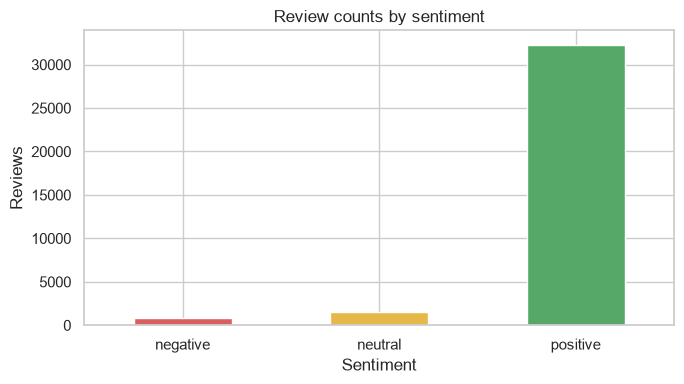

In [6]:
class_counts = df["sentiment"].value_counts().reindex(LABELS, fill_value=0)
class_summary = pd.DataFrame({"reviews": class_counts, "share": class_counts / len(df)})
display(class_summary.style.format({"reviews": "{:,.0f}", "share": "{:.1%}"}))
ax = class_counts.plot(kind="bar", color=["#d95f5f", "#e6b84a", "#55a868"], figsize=(7, 4))
ax.set(title="Review counts by sentiment", xlabel="Sentiment", ylabel="Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Create train, validation, and test splits

A stratified 60/20/20 split keeps the label distribution similar across sets. The validation set is used to choose among the five model configurations. The test set is kept aside until that choice is made, then used once for final reporting.

In [5]:
train_val_df, test_df = train_test_split(
    df, test_size=0.20, random_state=RANDOM_STATE, stratify=df["sentiment"]
)
train_df, validation_df = train_test_split(
    train_val_df,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=train_val_df["sentiment"],
)
for split_name, split_df in [("train", train_df), ("validation", validation_df), ("test", test_df)]:
    print(f"{split_name:10s}: {len(split_df):6,} rows ({len(split_df) / len(df):.1%})")
    print((split_df["sentiment"].value_counts(normalize=True).reindex(LABELS, fill_value=0).round(3)).to_dict())

train     : 20,775 rows (60.0%)
{'negative': 0.023, 'neutral': 0.043, 'positive': 0.933}
validation:  6,925 rows (20.0%)
{'negative': 0.023, 'neutral': 0.043, 'positive': 0.933}
test      :  6,925 rows (20.0%)
{'negative': 0.023, 'neutral': 0.043, 'positive': 0.933}


## 6. Train and compare five candidate models

Each vectorizer is fitted on training text only to prevent validation/test vocabulary leakage. Candidates match the project pipeline: TF-IDF with logistic regression (standard and class-balanced), TF-IDF with Multinomial Naive Bayes, TF-IDF with class-balanced LinearSVC, and Bag-of-Words with class-balanced logistic regression. We select by validation **macro F1**, giving each sentiment class equal weight.

In [7]:
candidates = {
    "TF-IDF + Logistic Regression": (
        TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english"),
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    ),
    "TF-IDF + Logistic Regression (balanced)": (
        TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english"),
        LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE),
    ),
    "TF-IDF + Multinomial Naive Bayes": (
        TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english"),
        MultinomialNB(),
    ),
    "TF-IDF + LinearSVC (balanced)": (
        TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english"),
        LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000),
    ),
    "BoW + Logistic Regression (balanced)": (
        CountVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2)),
        LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE),
    ),
}

X_train, y_train = train_df["review_text"], train_df["sentiment"]
X_validation, y_validation = validation_df["review_text"], validation_df["sentiment"]
validation_rows = []
fitted_candidates = {}

for name, (vectorizer_template, classifier_template) in candidates.items():
    vectorizer = clone(vectorizer_template)
    classifier = clone(classifier_template)
    train_features = vectorizer.fit_transform(X_train)
    validation_features = vectorizer.transform(X_validation)
    classifier.fit(train_features, y_train)
    predictions = classifier.predict(validation_features)
    precision, recall, class_f1, support = precision_recall_fscore_support(
        y_validation, predictions, labels=LABELS, zero_division=0
    )
    validation_rows.append({
        "Model": name,
        "Validation accuracy": accuracy_score(y_validation, predictions),
        "Validation macro precision": precision.mean(),
        "Validation macro recall": recall.mean(),
        "Validation macro F1": class_f1.mean(),
        "Validation weighted F1": f1_score(y_validation, predictions, average="weighted"),
        "Negative F1": class_f1[0],
        "Neutral F1": class_f1[1],
        "Positive F1": class_f1[2],
    })
    fitted_candidates[name] = (vectorizer, classifier)

comparison = pd.DataFrame(validation_rows).sort_values(
    ["Validation macro F1", "Validation accuracy"], ascending=False
).reset_index(drop=True)
display(comparison.style.format({col: "{:.3f}" for col in comparison.columns if col != "Model"}))
selected_name = comparison.loc[0, "Model"]
print(f"Selected on validation macro F1: {selected_name}")

,Model,Validation accuracy,Validation macro precision,Validation macro recall,Validation macro F1,Validation weighted F1,Negative F1,Neutral F1,Positive F1
0,TF-IDF + LinearSVC (balanced),0.907,0.499,0.514,0.505,0.910,0.323,0.237,0.956
1,TF-IDF + Logistic Regression (balanced),0.832,0.447,0.599,0.479,0.870,0.298,0.224,0.914
2,BoW + Logistic Regression (balanced),0.858,0.450,0.551,0.479,0.883,0.293,0.215,0.929
3,TF-IDF + Logistic Regression,0.936,0.675,0.390,0.421,0.911,0.215,0.079,0.968
4,TF-IDF + Multinomial Naive Bayes,0.933,0.644,0.335,0.326,0.901,0.012,0.000,0.966


Selected on validation macro F1: TF-IDF + LinearSVC (balanced)


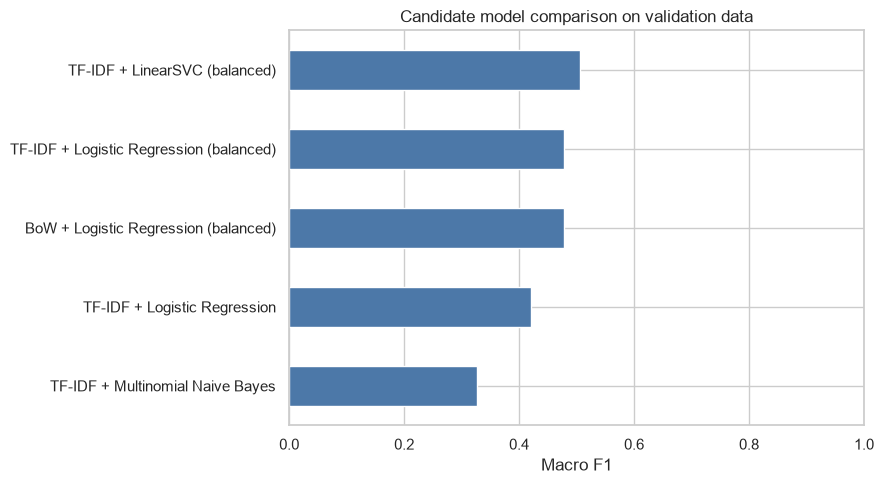

In [8]:
ax = comparison.sort_values("Validation macro F1").plot.barh(
    x="Model", y="Validation macro F1", legend=False, figsize=(9, 5), color="#4c78a8"
)
ax.set(title="Candidate model comparison on validation data", xlabel="Macro F1", ylabel="")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 7. Refit the selected model and evaluate on the test set

After choosing the model, fit a fresh vectorizer and classifier on all training plus validation data. Only now transform and score the test set. These final test metrics are the reportable estimate of performance on unseen reviews.

In [9]:
selected_vectorizer_template, selected_classifier_template = candidates[selected_name]
final_vectorizer = clone(selected_vectorizer_template)
final_classifier = clone(selected_classifier_template)
train_final_df = pd.concat([train_df, validation_df], axis=0)
X_train_final = train_final_df["review_text"]
y_train_final = train_final_df["sentiment"]
X_test, y_test = test_df["review_text"], test_df["sentiment"]

train_final_features = final_vectorizer.fit_transform(X_train_final)
test_features = final_vectorizer.transform(X_test)
final_classifier.fit(train_final_features, y_train_final)
test_predictions = final_classifier.predict(test_features)

test_accuracy = accuracy_score(y_test, test_predictions)
test_macro_precision, test_macro_recall, test_macro_f1, _ = precision_recall_fscore_support(
    y_test, test_predictions, average="macro", zero_division=0
)
test_weighted_f1 = f1_score(y_test, test_predictions, average="weighted")
test_metrics = pd.DataFrame([{
    "Model": selected_name,
    "Test accuracy": test_accuracy,
    "Test macro precision": test_macro_precision,
    "Test macro recall": test_macro_recall,
    "Test macro F1": test_macro_f1,
    "Test weighted F1": test_weighted_f1,
    "Test samples": len(y_test),
}])
display(test_metrics.style.format({
    "Test accuracy": "{:.2%}",
    "Test macro precision": "{:.2%}",
    "Test macro recall": "{:.2%}",
    "Test macro F1": "{:.2%}",
    "Test weighted F1": "{:.2%}",
    "Test samples": "{:,.0f}",
}))
print(classification_report(y_test, test_predictions, labels=LABELS, zero_division=0, digits=4))

,Model,Test accuracy,Test macro precision,Test macro recall,Test macro F1,Test weighted F1,Test samples
0,TF-IDF + LinearSVC (balanced),90.09%,50.07%,52.54%,51.17%,90.59%,"6,925"


              precision    recall  f1-score   support

    negative     0.3556    0.3951    0.3743       162
     neutral     0.1878    0.2367    0.2094       300
    positive     0.9587    0.9445    0.9515      6463

    accuracy                         0.9009      6925
   macro avg     0.5007    0.5254    0.5117      6925
weighted avg     0.9112    0.9009    0.9059      6925



## 8. Confusion matrix: inspect class-specific errors

Rows are actual labels and columns are predicted labels. The diagonal contains correct classifications; off-diagonal cells show which classes the model confuses. In this dataset, many neutral and negative reviews may be assigned to the much more common positive class.

,Predicted negative,Predicted neutral,Predicted positive
Actual negative,64,34,64
Actual neutral,30,71,199
Actual positive,86,273,6104


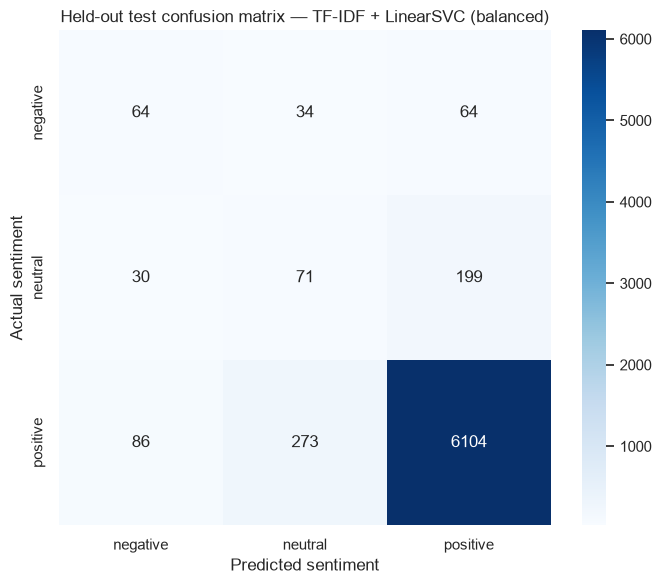

In [10]:
matrix = confusion_matrix(y_test, test_predictions, labels=LABELS)
confusion_table = pd.DataFrame(
    matrix,
    index=[f"Actual {label}" for label in LABELS],
    columns=[f"Predicted {label}" for label in LABELS],
)
display(confusion_table)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    matrix, annot=True, fmt="d", cmap="Blues",
    xticklabels=LABELS, yticklabels=LABELS, ax=ax
)
ax.set_title(f"Held-out test confusion matrix — {selected_name}")
ax.set_xlabel("Predicted sentiment")
ax.set_ylabel("Actual sentiment")
plt.tight_layout()
plt.show()

## 9. Save metrics, matrix, and trained model

The saved model includes the fitted text vectorizer and classifier so the app can transform new reviews consistently. The test set is not used to fit either component.

In [11]:
per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
    y_test, test_predictions, labels=LABELS, zero_division=0
)
per_class_metrics = pd.DataFrame({
    "Model": selected_name,
    "Sentiment": LABELS,
    "Precision": per_class_precision,
    "Recall": per_class_recall,
    "F1-score": per_class_f1,
    "Support": per_class_support,
})

comparison.to_csv(OUTPUT_DIR / "task1_model_comparison.csv", index=False)
test_metrics.to_csv(OUTPUT_DIR / "task1_test_metrics.csv", index=False)
per_class_metrics.to_csv(OUTPUT_DIR / "task1_per_class_metrics.csv", index=False)
confusion_table.to_csv(OUTPUT_DIR / "task1_confusion_matrix.csv", index=True)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_title(f"Held-out test confusion matrix — {selected_name}")
ax.set_xlabel("Predicted sentiment")
ax.set_ylabel("Actual sentiment")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "task1_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.close(fig)

model_artifact = {
    "classifier": final_classifier,
    "vectorizer": final_vectorizer,
    "labels": LABELS,
    "recommended_model": selected_name,
    "selection_metric": "validation_macro_f1",
    "validation_macro_f1": float(comparison.loc[0, "Validation macro F1"]),
    "test_accuracy": float(test_accuracy),
    "test_weighted_f1": float(test_weighted_f1),
}
joblib.dump(model_artifact, OUTPUT_DIR / "task1_recommended_model.joblib")
joblib.dump(model_artifact, MODELS_DIR / "task1_recommended_model.joblib")

print("Saved Task 1 artifacts:")
for path in sorted(OUTPUT_DIR.glob("task1_*")):
    print(f"- {path.relative_to(ROOT)}")
print(f"- {(MODELS_DIR / 'task1_recommended_model.joblib').relative_to(ROOT)}")

Saved Task 1 artifacts:
- outputs\task1_confusion_matrix.csv
- outputs\task1_confusion_matrix.png
- outputs\task1_model_comparison.csv
- outputs\task1_per_class_metrics.csv
- outputs\task1_recommended_model.joblib
- outputs\task1_test_metrics.csv
- models\task1_recommended_model.joblib


## 10. Conclusions

- The model is selected by validation macro F1, not by its performance on the final test set.
- Test accuracy and weighted F1 are high largely because positive reviews dominate this dataset.
- Negative and especially neutral reviews remain difficult; use their precision, recall, F1, and confusion-matrix rows when explaining model limitations.
- The model's softmax-transformed LinearSVC decision scores are not calibrated probabilities. If the app displays them as confidence scores, describe them as relative score-based estimates rather than statistically calibrated confidence.

For reproducibility, keep the dataset version fixed and run all cells from the beginning. Outputs are regenerated in `outputs/` and the selected artifact is copied to `models/`.